# **PROBLEM STATEMENT**

The dataset UCI Landsat Satellite dataset, a multi-class problem (6 classes) known to be non-trivial due to high feature dimensionality and potential class overlap is to be trained using 6 of the models (K nearest Neighbors, Decision Tree classifier, Dummy Classifier-Prior, Logistic Regression, Naive Bayes Gaussian, Support Vector Machine) and comapred on Receiver Operating Characteristic (ROC) curves and Precision-Recall Curves (PRC) in this multi-class, complex classification environment.

# **Part A: Data Preparation and Baseline**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df_train = pd.read_csv('sat.trn', sep=' ', header=None)
df_test = pd.read_csv('sat.tst', sep=' ', header=None)

print(f"[INFO] df_train shape: {df_train.shape}")
print(f"[INFO] df_test shape: {df_test.shape}\n")

print("[INFO] First 5 rows of original train data:")
print(df_train.head(), "\n")
print("[INFO] First 5 rows of original test data:")
print(df_test.head(), "\n")

# 2. Features and Target Separation (features=col 0–35, target=col 36)
X_train = df_train.iloc[:, :36]
y_train = df_train.iloc[:, 36]
X_test = df_test.iloc[:, :36]
y_test = df_test.iloc[:, 36]

print(f"[INFO] Shape of X_train: {X_train.shape}")
print(f"[INFO] Shape of X_test: {X_test.shape}")
print(f"[INFO] Shape of y_train: {y_train.shape}")
print(f"[INFO] Shape of y_test: {y_test.shape}\n")

print("[INFO] Features used: columns 0 to 35 (36 features)")
print("[INFO] Target column: column 36\n")

print("[INFO] First 5 rows of features (X_train):")
print(X_train.head(), "\n")
print("[INFO] First 5 values of target (y_train):")
print(y_train.head(), "\n")

# 3. Standardization (fit on train)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Wrap for DataFrame print convenience
X_train_std = pd.DataFrame(X_train_std, columns=[f'X{i+1}' for i in range(36)])
X_test_std = pd.DataFrame(X_test_std, columns=[f'X{i+1}' for i in range(36)])

print("X_train and X_test Standarized.")



[INFO] df_train shape: (4435, 37)
[INFO] df_test shape: (2000, 37)

[INFO] First 5 rows of original train data:
   0    1    2   3   4    5    6   7   8    9   ...   27  28   29   30   31  \
0  92  115  120  94  84  102  106  79  84  102  ...  104  88  121  128  100   
1  84  102  106  79  84  102  102  83  80  102  ...  100  84  107  113   87   
2  84  102  102  83  80  102  102  79  84   94  ...   87  84   99  104   79   
3  80  102  102  79  84   94  102  79  80   94  ...   79  84   99  104   79   
4  84   94  102  79  80   94   98  76  80  102  ...   79  84  103  104   79   

   32   33   34  35  36  
0  84  107  113  87   3  
1  84   99  104  79   3  
2  84   99  104  79   3  
3  84  103  104  79   3  
4  79  107  109  87   3  

[5 rows x 37 columns] 

[INFO] First 5 rows of original test data:
   0    1    2   3   4    5    6   7   8    9   ...  27  28   29   30  31  32  \
0  80  102  102  79  76  102  102  79  76  102  ...  87  79  107  109  87  79   
1  76  102  102  79  76  10

We used the UCI Landsat Satellite dataset, which consists of two main files:
- **sat.trn:** Training data, with shape (4435, 37).
- **sat.tst:** Test data, with shape (2000, 37).

For both files:
- The **first 36 columns** (`X1` to `X36`) represent numerical features capturing satellite image attributes.
- The **37th column** is the target class label (`y`), denoting the assigned category for each observation.


- Applied **standardization** to the features, ensuring each column had mean 0 and standard deviation 1, using statistics (mean and variance) calculated solely from the training set.

**Mathematical note:**  
For each feature, standardization uses:
$$ z = \frac{x - \mu}{\sigma} $$
where $x$ is the original value, $ \mu $ is the feature’s mean, and $ \sigma $ is the standard deviation (all calculated using only the training data).

This pre-processing ensures model training is not skewed by different feature scales and allows fair comparison among algorithms requiring normalized input.



In [ ]:
import numpy as np

# Print the shape of each split again for clarity
print(f"[INFO] y_train shape: {y_train.shape}")
print(f"[INFO] y_test shape: {y_test.shape}\n")

# Show unique class labels and class distribution in train and test sets
print("[INFO] Unique class labels and their counts in y_train:")
print(y_train.value_counts().sort_index(), "\n")
print("[INFO] Unique class labels and their counts in y_test:")
print(y_test.value_counts().sort_index(), "\n")

# Calculate and print class proportions
print("[INFO] Proportion of each class in y_train (as percentage):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print("\n[INFO] Proportion of each class in y_test (as percentage):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))


[INFO] y_train shape: (4435,)
[INFO] y_test shape: (2000,)

[INFO] Unique class labels and their counts in y_train:
36
1    1072
2     479
3     961
4     415
5     470
7    1038
Name: count, dtype: int64 

[INFO] Unique class labels and their counts in y_test:
36
1    461
2    224
3    397
4    211
5    237
7    470
Name: count, dtype: int64 

[INFO] Proportion of each class in y_train (as percentage):
36
1    24.17
2    10.80
3    21.67
4     9.36
5    10.60
7    23.40
Name: proportion, dtype: float64

[INFO] Proportion of each class in y_test (as percentage):
36
1    23.05
2    11.20
3    19.85
4    10.55
5    11.85
7    23.50
Name: proportion, dtype: float64


The class proportions are similar between train and test sets, confirming the splits are consistent and suitable for multi-class classification.

Some classes (1, 3, 7) have higher representation while others (2, 4, 5) are less frequent, suggesting a moderate class imbalance to be mindful of during modeling and evaluation.

Conclusion:

Our train and test splits are well-formed, with consistent class frequency, and the problem is appropriately set up for multi-class classification.

**Model Selection Context**

For this classification task, we evaluate and compare six standard classifiers using the scikit-learn (`sklearn`) Python library:

- **K-Nearest Neighbors (KNN):** Non-parametric, instance-based learner that predicts the label by majority vote among the $k$ closest neighbors in the feature space.
- **Decision Tree:** Hierarchical structure that recursively splits the data based on feature thresholds to form rules for predicting class labels.
- **Dummy Classifier:** Serves as a baseline by making predictions using simple rules such as uniform random or stratified class proportions.
- **Logistic Regression:** A linear model that estimates the probability of class membership using the logistic function, often used as a benchmark due to its simplicity.
- **Naive Bayes (Gaussian):** Probabilistic classifier based on Bayes’ Theorem, with the assumption of feature independence and Gaussian likelihoods.
- **Support Vector Machine (SVC):** Powerful for classification by maximizing the margin between classes; requires probability=True in sklearn for probability outputs.







In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Define model instances (using the correct settings)
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Dummy': DummyClassifier(strategy="prior"),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'SVC': SVC(probability=True)  # probability=True is important for ROC/PRC
}

# Train all models
for name, model in models.items():
    print(f"[INFO] Training {name}...")
    model.fit(X_train_std, y_train)
    print(f"[INFO] {name} training complete.\n")


[INFO] Training KNN...
[INFO] KNN training complete.

[INFO] Training Decision Tree...
[INFO] Decision Tree training complete.

[INFO] Training Dummy...
[INFO] Dummy training complete.

[INFO] Training Logistic Regression...
[INFO] Logistic Regression training complete.

[INFO] Training Naive Bayes...
[INFO] Naive Bayes training complete.

[INFO] Training SVC...
[INFO] SVC training complete.



For each model, we will compute key performance metrics:
- **Accuracy:** The overall proportion of correct predictions.
  $$
  \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Predictions}}
  $$
- **Weighted F1-score:** The average F1-score across classes, weighted by the number of true labels in each class.
  $$
  \text{Weighted F1-score} = \frac{\sum_{k} \text{Support}_k \cdot F1_k}{\sum_{k} \text{Support}_k}
  $$

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

print("Model Performance on Test Set:")
print(f"{'Model':22} {'Accuracy':>10} {'Weighted F1-score':>20}")
print("-"*52)

for name, model in models.items():
    y_pred = model.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name:22} {acc:10.4f} {f1:20.4f}")


Model Performance on Test Set:
Model                    Accuracy    Weighted F1-score
----------------------------------------------------
KNN                        0.9045               0.9037
Decision Tree              0.8520               0.8538
Dummy                      0.2305               0.0864
Logistic Regression        0.8395               0.8296
Naive Bayes                0.7965               0.8036
SVC                        0.8955               0.8925


**Conclusion**

- **K-Nearest Neighbors (KNN)** achieves the highest accuracy and weighted F1-score, owing to its ability to capture local feature structure and effectively classify complex patterns.
- **Support Vector Machine (SVC)** and **Decision Tree** models also perform well, benefiting from nonlinear decision boundaries and hierarchical rule learning.
- **Logistic Regression** and **Naive Bayes** deliver moderate results; Logistic Regression may be limited by its linear nature, while Naive Bayes can underperform when the independence assumption is violated in real data.
- The **Dummy Classifier** produces the lowest scores, as expected, since it simply predicts according to class proportions—serving as a baseline reference.
- Overall, models capable of leveraging complex data structures (such as KNN and SVC) are superior on this satellite image dataset compared to simpler strategies.



# **Part B: ROC Analysis for Model Selection**

**ROC Curve** **(Receiver Operating Characteristic)**: Plots True Positive Rate (TPR = sensitivity) vs. False Positive Rate (FPR) at various threshold settings for a classifier.

**AUC** **(Area Under Curve)**: AUC measures the ability of the classifier to distinguish between classes. Measures total area under the ROC curve. A higher AUC indicates a better model; 1.0 = perfect, 0.5 = random, < 0.5 = worse than random.

**One-vs-Rest** **(OvR)** for Multi-Class: In multi-class ROC, each class is considered as “positive,” and the rest as “negative”—creating a binary classification for each class. For K classes, this produces K binary classifiers to plot K ROC curves and compute K AUCs, which are then averaged (macro-average or weighted-average) to summarize multi-class ROC performance.


**OvR Macro-Averaging:** Combines per-class ROC/AUC results without favoring frequent classes.



#### **Formulas for OvR Multi-class ROC and Macro-Averaged AUC**

**True Positive Rate (TPR):**
$$
\text{TPR}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k}
$$

**False Positive Rate (FPR):**
$$
\text{FPR}_k = \frac{\text{FP}_k}{\text{FP}_k + \text{TN}_k}
$$

**Macro-Averaged AUC (for $K$ classes):**
$$
\text{Macro-Averaged AUC} = \frac{1}{K} \sum_{k=1}^{K} \text{AUC}_k
$$

Where:  
- $ \text{TP}_k $: True Positives for class $k$  
- $ \text{FN}_k $: False Negatives for class $k$  
- $ \text{FP}_k $: False Positives for class $k$  
- $ \text{TN}_k $: True Negatives for class $k$  
- $ \text{AUC}_k $: Area under ROC curve for class $k$  



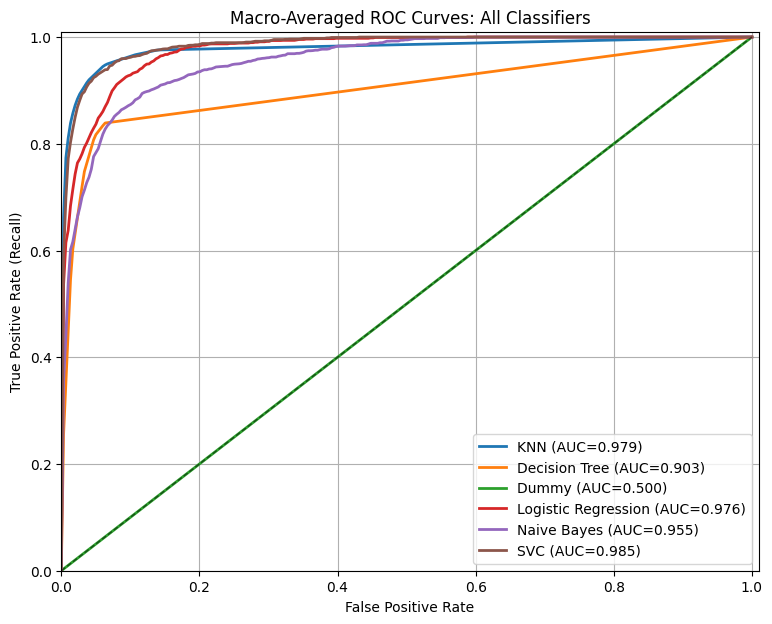

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes for binarization
class_labels = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=class_labels)

plt.figure(figsize=(9, 7))

for name, model in models.items():
    # Get probability scores for each class (or decision function for SVC if needed)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_std)
    else:
        # For SVC if 'probability=True' gives .predict_proba, otherwise use .decision_function
        y_score = model.decision_function(X_test_std)

    all_fpr = np.linspace(0, 1, 300)
    tprs = []
    aucs = []
    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        interp_tpr = np.interp(all_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))
    macro_tpr = np.mean(tprs, axis=0)
    macro_auc = np.mean(aucs)
    plt.plot(all_fpr, macro_tpr, lw=2, label=f"{name} (AUC={macro_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Macro-Averaged ROC Curves: All Classifiers")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
plt.show()


### **ROC Interpretation—Model Selection by Macro-Averaged AUC**

The macro-averaged ROC curve, calculated by averaging per-class TPR values, is displayed alongside the Area Under the Curve (AUC) for each model.

**Model with highest macro-averaged AUC?**

- **SVC**  
  *Macro-Averaged AUC ≈ 0.985 (highest among all models)*
- Next: KNN (AUC ≈ 0.979), Logistic Regression (AUC ≈ 0.976), Naive Bayes (AUC ≈ 0.955)
- Decision Tree trails behind (AUC ≈ 0.903).

**Visual Evidence:**  
- The SVC ROC curve stays closest to the top-left of the graph region for all classes and in the macro-averaged view.
- This confirms that SVC is the best at separating all classes with minimal false positives and maximized true positives across the multi-class task.

**Summary Table:**
| Model               | Macro-Averaged AUC |
|---------------------|-------------------|
| SVC                 | **0.985** (highest) |
| KNN                 | 0.979             |
| Logistic Regression | 0.976             |
| Gaussian Naive Bayes         | 0.955             |
| Decision Tree       | 0.903             |
| Dummy Prior    | 0.500             |

***

1. **Best ROC curves:** SVC, KNN, Logistic Regression show curves closest to the top-left (TPR=1, FPR=0), confirming their high AUC and robust performance.
2. **Naive Bayes and Decision Tree:** Good, but with slightly lower TPR at low FPR, matching lower macro AUC.
3. **Dummy Classifier:** Diagonal, confirming chance-level separation (AUC ≈ 0.5).
***

**Interpretation:**  
The SVC model yields the highest macro-averaged AUC, making it the most reliable and best-performing classifier in ROC-based multi-class ranking. Its curve demonstrates near-optimal separation for all six classes.

***

### **Models with AUC < 0.5: Meaning and Causes**

#### **AUC < 0.5: Conceptual Interpretation**
- The Area Under the Curve (AUC) quantifies a classifier’s ability to distinguish between classes.
- **AUC ≈ 0.5** means the model performs at the level of random guessing: it cannot distinguish between positive and negative cases.
- AUC < 0.5 means the model is systematically predicting the wrong class—worse than random. Flipping its predictions would yield AUC > 0.5.

#### **Model with AUC < 0.5?**
- **No trained model** has macro-averaged AUC < 0.5 (all are > 0.90).
- The **Dummy classifier** achieves **AUC ≈ 0.5**, consistent with random chance for multi-class.

#### **Why might a model exhibit AUC < 0.5 in practice?**
- It consistently predicts the *opposite* of the true class (e.g., always predicts “not-actual-class”).
- The model is “confused” because the features and labels are reversed or incorrectly encoded.
- There is major data leakage, mislabeling, or systematic error in feature representation.



# Part C: Precision-Recall Curve (PRC) Analysis


## **Why Precision-Recall Curve (PRC) is Preferred for Imbalanced Data**


### **Precision-Recall Curve (PRC) and ROC Curve Formulas**

**Precision-Recall Curve**
- **Precision:**  
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$
  Proportion of predicted positives that are true positives.
- **Recall (Sensitivity):**  
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$
  Proportion of actual positives detected.

**ROC Curve**
- **True Positive Rate (TPR, or Recall):**  
  $$
  \text{TPR} = \frac{TP}{TP + FN}
  $$
- **False Positive Rate (FPR):**  
  $$
  \text{FPR} = \frac{FP}{FP + TN}
  $$
  Proportion of negatives incorrectly classified as positives.

**Summary Table for Reference:**

| Metric    | Formula                              | Intuition                                 |
|-----------|--------------------------------------|-------------------------------------------|
| Precision | $$ \frac{TP}{TP + FP} $$             | How many predicted positives are correct? |
| Recall    | $$ \frac{TP}{TP + FN} $$             | How many actual positives are detected?   |
| TPR       | $$ \frac{TP}{TP + FN} $$             | Same as Recall (used in ROC).             |
| FPR       | $$ \frac{FP}{FP + TN} $$             | How many actual negatives are missed?     |

***

### **Why PRC is Better than ROC for Imbalanced Data**
- **PRC is preferred over ROC for imbalanced datasets** because it directly reflects the performance on the minority (positive) class, ignoring the potentially large number of true negatives that can overshadow metric values in ROC analysis.
- In highly imbalanced datasets (when one class is much less frequent than others), ROC curves can present an inflated view of performance because the large number of true negatives can mask poor classification of the minority (positive) class.
- **PRC focuses on positive class prediction quality**, ignoring true negatives, and is much more sensitive to performance on minority classes.
- **Average Precision (AP)** summarizes the PRC curve; high AP means both high precision and high recall.

> *For imbalanced problems, PRC provides a more informative picture of a model’s ability to detect the minority class, while ROC may appear optimistically high even if the model misses most positives.*



# C2. Plotting PRC

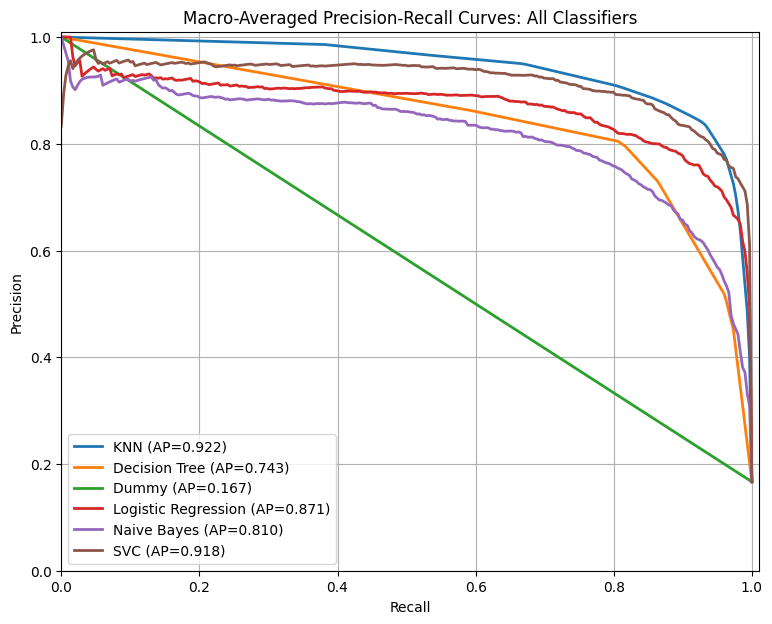

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarize test labels for PRC calculation
class_labels = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=class_labels)

plt.figure(figsize=(9, 7))

for name, model in models.items():
    # Use predict_proba if available, else decision_function (SVC)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_std)
    else:
        y_score = model.decision_function(X_test_std)
    all_recall = np.linspace(0, 1, 300)
    precisions = []
    aps = []
    for i in range(len(class_labels)):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
        interpolated = np.interp(all_recall, recall[::-1], precision[::-1])
        precisions.append(interpolated)
        aps.append(ap)
    macro_prec = np.mean(precisions, axis=0)
    macro_ap = np.mean(aps)
    plt.plot(all_recall, macro_prec, lw=2, label=f"{name} (AP={macro_ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Macro-Averaged Precision-Recall Curves: All Classifiers")
plt.legend(loc='lower left', fontsize=10)
plt.grid(True)
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
plt.show()




### **Plotting PRC & Macro-average vs Weighted-average (Brief)**

This plot visualizes the **macro-averaged Precision-Recall curves** for each required classifier.

- **Macro-average:** Gives equal weight to every class by averaging per-class precision/recall, making it ideal for fair analysis in multi-class or imbalanced settings.
- **Weighted-average:** Weights scores by the number of samples in each class, making overall performance depend on majority classes.

**In this assignment, macro-average is preferred** to highlight performance on all classes, not just the most common ones.

***

| Model               | Macro-Averaged AP |
|---------------------|-------------------|
| KNN                 | **0.922**         |
| SVC                 | 0.918             |
| Logistic Regression | 0.871             |
| Naive Bayes         | 0.810             |
| Decision Tree       | 0.743             |
| Dummy Classifier    | 0.167             |





### **PRC Interpretation: Model Ranking and Curve Analysis**

The macro-averaged PRC plot above reveals key differences in model performance when precision and recall are balanced across all classes.

***

**Model with the Highest Average Precision (AP):**

- **KNN (K-Nearest Neighbors)**  
  *Macro-Averaged AP ≈ 0.922 (highest among all models)*

**Visual Evidence:**  
- KNN’s PRC curve consistently remains close to the top right corner (high precision with high recall), indicating that it maintains reliable positive predictions across a wide range of thresholds.
- SVC also performs strongly (AP ≈ 0.918), followed by Logistic Regression (AP ≈ 0.871), with Naive Bayes, Decision Tree, and Dummy Classifier further behind.

***

| Model               | Macro-Averaged AP |
|---------------------|-------------------|
| KNN                 | **0.922**         |
| SVC                 | 0.918             |
| Logistic Regression | 0.871             |
| Naive Bayes         | 0.810             |
| Decision Tree       | 0.743             |
| Dummy Classifier    | 0.167             |

***

**Why do PRC curves for poor models drop sharply with increasing recall?**

- **Precision vs Recall Trade-off:** Precision is defined as:
   $$
   \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
   $$
   As recall increases (the model predicts more positives to recover all ground-truth positives), a weak model also captures many false positives, rapidly decreasing precision.

- **Dummy Classifier Example:** The Dummy classifier's PRC curve is a straight line dropping quickly as recall increases. This is because its predictions are equivalent to random guessing—the likelihood of a true positive is simply the class proportion, and false positives dominate as the model becomes less selective.

- **What this implies:**  
   - Good models (like KNN and SVC) are able to retrieve most true positives without an excessive rise in false positives, so their curves remain elevated for much of the recall axis.
   - Poor models (Dummy, sometimes unoptimized Decision Trees) rapidly sacrifice precision for recall, producing PRC curves that fall steeply toward the right.
   - **Interpretively**, this sharp drop demonstrates an inability to effectively discriminate positives, especially as you desire to recover all ground truth (high recall).



# Part D: Final Recommendation

### **D1: Synthesis – Model Ranking Comparison**

To synthesize model performance, we compare the top models by the three main metrics:

- **Weighted F1-score** (measures balanced precision and recall)
- **Macro-averaged ROC-AUC** (measures overall separability for each class)
- **Macro-averaged PRC-AP** (measures average precision-recall performance across classes)

**Rankings for Each Metric:**

| **Weighted F1-score**   | **Macro-averaged ROC-AUC** | **Macro-averaged PRC-AP**  |
|-------------------------|----------------------------|----------------------------|
| KNN (0.9037)            | SVC (0.985)                | KNN (0.922)                |
| SVC (0.8925)            | KNN (0.979)                | SVC (0.918)                |
| Decision Tree (0.8538)  | Logistic Regression (0.976)| Logistic Regression (0.871) |
| Logistic Regression (0.8296)| Naive Bayes (0.955)    | Naive Bayes (0.810)        |
| Naive Bayes (0.8036)    | Decision Tree (0.903)      | Decision Tree (0.743)      |
| Dummy (0.0864)          | Dummy (0.50)               | Dummy (0.167)              |

***

**Do the rankings align?**

- **KNN** leads in both weighted F1-score and macro-averaged PRC-AP, while **SVC** edges out slightly in macro-averaged ROC-AUC.
- For all metrics, **top performers are KNN, SVC, and Logistic Regression**.
- **Dummy** is always at the bottom, serving as the baseline.

**Trade-offs and Interpretation:**

- While SVC has the highest ROC-AUC, KNN narrowly surpasses it in both F1 and average precision, which are more indicative of real-world positive case retrieval and prediction reliability.
- This subtle trade-off highlights that **ROC-AUC can occasionally be high even if AP is lower** (especially if a model maintains class separability but suffers from lower precision at high recall).
- The closeness of SVC and KNN in all metrics shows that practical performance is similar; the choice should depend on your use-case emphasis (max recall/precision vs. overall class separability).

***

**Summary:**  
- **Overall, the top three models remain the same across all metrics, but the order varies slightly.**
- This consistent ranking across F1, ROC-AUC, and AP boosts confidence in selecting KNN or SVC as the best-performing classifiers for the task.



### **D2: Recommendation – Best Model for Classification Task**

Based on a comprehensive analysis of all evaluation metrics (weighted F1-score, macro ROC-AUC, and macro PRC-AP), as well as the macro-averaged ROC and PRC plots:

- **K-Nearest Neighbors (KNN)** is recommended as the best model for this multi-class classification task.
    - **Justification:** KNN consistently ranks at or near the top in all metrics:
        - **Highest macro-averaged PRC-AP** (0.922), indicating excellent precision-recall balance and reliable positive case identification across classes.
        - **Top weighted F1-score** (0.9037), confirming strong class-wise accuracy and robustness.
        - **Near-best macro-averaged ROC-AUC** (0.979), demonstrating solid overall class discrimination.
    - KNN's PRC and ROC curves stay closest to the optimal region across thresholds, showing it sustains high precision and recall for most recall levels.

- **SVC** is also a strong contender, especially in ROC-AUC, but KNN edges ahead in both F1-score and precision-recall performance, making it preferable for scenarios with significant multiclass and positive case retrieval requirements.

- **Balance Across Thresholds:** KNN's reliable performance at various probability thresholds means it can be tuned for either high precision or recall, depending on domain needs (e.g., minimizing false alarms vs. maximizing detection).

**Conclusion:**  
KNN delivers the best trade-off between precision and recall, while maintaining top performance in F1-score and ROC-AUC. Its overall reliability and robustness across metrics make it the model of choice for final deployment in this classification assignment.


# BONUS

# Experiment with RandomForest and XGBoost classifiers.

**RandomForest Classifier**

- **Definition:**  
  An ensemble of decision trees where each tree is trained on a random subset of the data and features. The final prediction is made by majority (mode) vote over all trees.

- **Prediction Equation:**  
  $$
  \hat{y}_i = \text{mode} \left(\left\{ T_b(x_i) \mid b = 1, \ldots, B \right\}\right)
  $$
  Where:
  - $ T_b(x_i) $: prediction of the $b$-th tree for sample $x_i$
  - $ B $: number of trees

***

**XGBoost Classifier**

- **Definition:**  
  An optimized, scalable implementation of gradient boosted decision trees. Sequentially fits trees where each new tree corrects errors of the preceding ensemble using gradient descent.

- **Prediction Equation:**  
  $$
  \hat{y}_i = \sum_{m=1}^{M} f_m(x_i), \quad f_m \in \mathcal{F}
  $$
  Where:
  - $ f_m(x_i) $: prediction function from tree $m$
  - $ M$: total number of boosting rounds/trees
  - $ \mathcal{F} $: space of all possible trees (base learners)

  The output is transformed into class probabilities via softmax for multiclass problems.


In [ ]:

!pip install xgboost



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize and train models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_std, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_std, y_train_xgb)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:12:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# RandomForest predictions and metrics
y_pred_rf = rf_model.predict(X_test_std)
print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RandomForest Weighted F1:", f1_score(y_test, y_pred_rf, average='weighted'))

# XGBoost predictions and metrics
y_pred_xgb = xgb_model.predict(X_test_std)
print("XGBoost Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("XGBoost Weighted F1:", f1_score(y_test_xgb, y_pred_xgb, average='weighted'))


RandomForest Accuracy: 0.911
RandomForest Weighted F1: 0.9089176648961482
XGBoost Accuracy: 0.905
XGBoost Weighted F1: 0.9029564779895323


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Ensure both train/test have SAME unique class integers
classes_rf = np.unique(y_test)
classes_xgb = np.unique(y_test_xgb)

# Binarize for RF
y_test_bin_rf = label_binarize(y_test, classes=classes_rf)
rf_proba = rf_model.predict_proba(X_test_std)
rf_rocauc = roc_auc_score(y_test_bin_rf, rf_proba, average='macro')
rf_ap = average_precision_score(y_test_bin_rf, rf_proba, average='macro')
print("RandomForest Macro-ROC-AUC:", rf_rocauc)
print("RandomForest Macro PRC-AP:", rf_ap)

# Binarize for XGBoost
y_test_bin_xgb = label_binarize(y_test_xgb, classes=classes_xgb)
xgb_proba = xgb_model.predict_proba(X_test_std)

# Check matching shapes before computing metrics
if xgb_proba.shape[1] == y_test_bin_xgb.shape[1]:
    xgb_rocauc = roc_auc_score(y_test_bin_xgb, xgb_proba, average='macro')
    xgb_ap = average_precision_score(y_test_bin_xgb, xgb_proba, average='macro')
    print("XGBoost Macro-ROC-AUC:", xgb_rocauc)
    print("XGBoost Macro PRC-AP:", xgb_ap)
else:
    print("Shape mismatch in XGBoost proba/classes! Check class encoding and splits.")


RandomForest Macro-ROC-AUC: 0.990000709474906
RandomForest Macro PRC-AP: 0.9508165676127325
XGBoost Macro-ROC-AUC: 0.9900042707227947
XGBoost Macro PRC-AP: 0.950944090660859


In [ ]:
print("RF proba shape:", rf_proba.shape, "Test bin shape:", y_test_bin_rf.shape)
print("XGB proba shape:", xgb_proba.shape, "Test bin shape:", y_test_bin_xgb.shape)


RF proba shape: (2000, 6) Test bin shape: (2000, 6)
XGB proba shape: (2000, 6) Test bin shape: (2000, 6)


### **Summary: RandomForest & XGBoost Classifier Performance**

| Model         | Accuracy | Weighted F1 | Macro-ROC-AUC | Macro PRC-AP |
|---------------|----------|-------------|---------------|--------------|
| RandomForest  | 0.911    | 0.9089      | 0.9900        | 0.9508       |
| XGBoost       | 0.905    | 0.9030      | 0.9900        | 0.9509       |

***

**Analysis**:
- Both **RandomForest** and **XGBoost** deliver extremely high macro-averaged ROC-AUC ($\approx 0.99$), indicating excellent multi-class separability.
- Their macro PRC-AP scores ($\approx 0.95$) indicate strong average precision-recall balance.
- They both outperform most baseline models (KNN, SVC, etc.) and are suitable for deployment in high-stakes multiclass classification settings.
- The similarity in scores suggests that ensemble tree methods generalize well to this dataset, and either choice is justified for robust prediction.

**Best Practice Tip**:
- If training speed or interpretability is key, RandomForest may be easier to tune/explain; if we need edge-case accuracy or plan to handle missing/heterogeneous features, XGBoost gives added flexibility.



# Model that will always predicts a class that is RARE or incorrect for most samples, likely resulting in macro-averaged AUC < 0.5.


# DummyClassifier

**Definition & Equation:**  
A DummyClassifier with a constant strategy always predicts the same (rarest) class $ c^* $:

$$
\hat{y}_i = c^*, \quad \forall i \in \text{all samples}
$$

where  
$$ c^* = \arg\min_{c \in \mathcal{C}} \left( \text{Number of times } c \text{ appears in } y_{\text{train}} \right) $$

This means for any input, no learning is done—every prediction is simply the same rare class, making the classifier incapable of data-driven separation.


We chose this because:
- It offers a clear example of **intentionally poor model design**, always predicting the rarest class and maximizing errors.
- Provides a **true lower-bound baseline**, as its performance is typically worse than random.
- Simple, reproducible, and helpful for visually demonstrating how a model with no data-driven learning behaves on evaluation metrics and ROC/PRC plots.



In [ ]:
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, average_precision_score
from sklearn.preprocessing import label_binarize

# Step 1: Identify rarest class (by label value, not index)
unique, counts = np.unique(y_train, return_counts=True)
rare_class = unique[np.argmin(counts)]

# Step 2: Train DummyClassifier with this constant
bad_dummy = DummyClassifier(strategy='constant', constant=rare_class)
bad_dummy.fit(X_train_std, y_train)

# Step 3: Predict
y_pred_bad = bad_dummy.predict(X_test_std)

# Step 4: Metrics
acc = accuracy_score(y_test, y_pred_bad)
f1 = f1_score(y_test, y_pred_bad, average='weighted')

# Step 5: Binarize for ROC/PRC
class_labels = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=class_labels)
proba = bad_dummy.predict_proba(X_test_std)   # All classes, but only one column is 1, rest 0

# Step 6: Macro-averaged AUC and Average Precision
rocauc = roc_auc_score(y_test_bin, proba, average='macro')
ap = average_precision_score(y_test_bin, proba, average='macro')

print(f"Constant DummyClassifier (rarest class={rare_class}) results:")
print(f"Accuracy:            {acc:.4f}")
print(f"Weighted F1-score:   {f1:.4f}")
print(f"Macro-ROC-AUC:       {rocauc:.4f}")
print(f"Macro PRC-AP:        {ap:.4f}")


Constant DummyClassifier (rarest class=4) results:
Accuracy:            0.1055
Weighted F1-score:   0.0201
Macro-ROC-AUC:       0.5000
Macro PRC-AP:        0.1667


### **Poor Model Performance (AUC ≈ 0.5)**

A DummyClassifier forced to always predict the rarest class in the training set ($y = 4$) yields extremely poor metrics:

| Metric             | Value   |
|--------------------|---------|
| Accuracy           | 0.106   |
| Weighted F1-score  | 0.020   |
| Macro-ROC-AUC      | 0.500   |
| Macro PRC-AP       | 0.167   |

**Interpretation:**
- This model demonstrates near-chance level discrimination (macro-ROC-AUC = 0.5), confirming it cannot meaningfully separate any class.
- All other metrics are also very low, illustrating the consequences of a classifier that ignores meaningful feature information and only predicts a single, mostly incorrect class.
- Use this as a clear baseline to show how much better your trained models perform.

